# MemShield — Full Pipeline Evaluation
**CICMalMem-2022 · Random Forest Binary Classifier**

Covers:
1. Data loading & exploration
2. Train / Val / Test split (70 / 15 / 15)
3. Model training
4. All binary classification metrics
5. 5-fold cross-validation
6. Feature importance

## 0 · Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Environment ready.')

Environment ready.


## 1 · Dataset Path & Structure

In [2]:
from modules.classifier import load_data, split_data, DATASET_PATH

X, y, feature_names = load_data(DATASET_PATH)

print(f'Samples (after dedup) : {X.shape[0]:,}')
print(f'Features              : {X.shape[1]}')
print(f'Benign                : {(y == 0).sum():,}  ({(y == 0).mean()*100:.1f}%)')
print(f'Malware               : {(y == 1).sum():,}  ({(y == 1).mean()*100:.1f}%)')

15:24:15  INFO     Loading dataset from /home/blanca/AdaptiveMemoryAnalysis2/dataset/Obfuscated-MalMem2022.csv


15:24:15  INFO     Removed 534 duplicate rows (58596 → 58062)


15:24:15  INFO     Loaded 58062 samples, 55 features  |  classes: {'Benign': np.int64(29231), 'Malware': np.int64(28831)}


Samples (after dedup) : 58,062
Features              : 55
Benign                : 29,231  (50.3%)
Malware               : 28,831  (49.7%)


In [3]:
from modules.classifier import load_data, split_data, DATASET_PATH

X, y, feature_names = load_data(DATASET_PATH)

print(f'Samples  : {X.shape[0]:,}')
print(f'Features : {X.shape[1]}')
print(f'Benign   : {(y == 0).sum():,}  ({(y == 0).mean()*100:.1f}%)')
print(f'Malware  : {(y == 1).sum():,}  ({(y == 1).mean()*100:.1f}%)')

15:24:15  INFO     Loading dataset from /home/blanca/AdaptiveMemoryAnalysis2/dataset/Obfuscated-MalMem2022.csv


15:24:16  INFO     Removed 534 duplicate rows (58596 → 58062)


15:24:16  INFO     Loaded 58062 samples, 55 features  |  classes: {'Benign': np.int64(29231), 'Malware': np.int64(28831)}


Samples  : 58,062
Features : 55
Benign   : 29,231  (50.3%)
Malware  : 28,831  (49.7%)


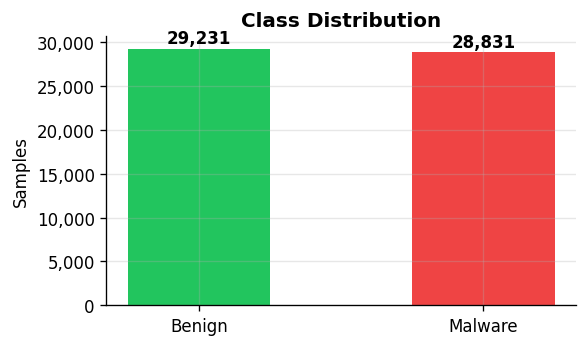

In [4]:
# Class distribution
fig, ax = plt.subplots(figsize=(5, 3))
counts = np.bincount(y)
bars = ax.bar(['Benign', 'Malware'], counts, color=['#22C55E', '#EF4444'], width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Samples')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 2 · Split

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}
for name, labels in splits.items():
    print(f'{name:<12}: {len(labels):>6,} samples  '
          f'| Benign {(labels==0).sum():>5,}  Malware {(labels==1).sum():>5,}')

15:24:17  INFO     Split  →  train: 40643 (70%)  |  val: 8709 (15%)  |  test: 8710 (15%)


Train       : 40,643 samples  | Benign 20,461  Malware 20,182
Validation  :  8,709 samples  | Benign 4,385  Malware 4,324
Test        :  8,710 samples  | Benign 4,385  Malware 4,325


## 3 · Train

In [6]:
from modules.classifier import train_model

model = train_model(X_train, y_train)
print('Model trained.')

15:24:17  INFO     Training RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2, max_features=sqrt, class_weight=balanced)


15:24:21  INFO     Training complete in 4.67 s


Model trained.


## 4 · Binary Classification Metrics

All metrics computed on **Validation** and **Test** sets side-by-side.

In [7]:
def full_binary_metrics(model, X, y, split_name=''):
    """Compute every standard binary classification metric."""
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    metrics = {
        # Threshold-based
        'Accuracy':                accuracy_score(y, y_pred),
        'Balanced Accuracy':       balanced_accuracy_score(y, y_pred),
        'Precision (Macro)':       precision_score(y, y_pred, average='macro'),
        'Precision (Weighted)':    precision_score(y, y_pred, average='weighted'),
        'Precision — Benign':      precision_score(y, y_pred, pos_label=0, average='binary'),
        'Precision — Malware':     precision_score(y, y_pred, pos_label=1, average='binary'),
        'Recall / Sensitivity':    recall_score(y, y_pred, pos_label=1, average='binary'),
        'Recall (Macro)':          recall_score(y, y_pred, average='macro'),
        'Specificity (TNR)':       tn / (tn + fp),
        'False Positive Rate':     fp / (fp + tn),
        'False Negative Rate':     fn / (fn + tp),
        'Negative Pred. Value':    tn / (tn + fn) if (tn + fn) > 0 else float('nan'),
        'F1 — Malware':            f1_score(y, y_pred, pos_label=1, average='binary'),
        'F1 — Benign':             f1_score(y, y_pred, pos_label=0, average='binary'),
        'F1 (Macro)':              f1_score(y, y_pred, average='macro'),
        'F1 (Weighted)':           f1_score(y, y_pred, average='weighted'),
        'Matthews Corr. Coeff.':   matthews_corrcoef(y, y_pred),
        "Cohen's Kappa":           cohen_kappa_score(y, y_pred),
        # Probability-based
        'ROC-AUC':                 roc_auc_score(y, y_proba),
        'PR-AUC (Avg Precision)':  average_precision_score(y, y_proba),
        'Log Loss':                log_loss(y, y_proba),
        'Brier Score':             brier_score_loss(y, y_proba),
        # Counts
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
    }

    return metrics, y_pred, y_proba


val_metrics,  val_pred,  val_proba  = full_binary_metrics(model, X_val,  y_val,  'Validation')
test_metrics, test_pred, test_proba = full_binary_metrics(model, X_test, y_test, 'Test')

print('Metrics computed.')

Metrics computed.


In [8]:
# Formatted comparison table
df = pd.DataFrame({'Validation': val_metrics, 'Test': test_metrics})

count_rows = ['TP', 'TN', 'FP', 'FN']
float_rows  = [r for r in df.index if r not in count_rows]

styled = df.loc[float_rows].style \
    .format('{:.6f}') \
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, subset=['Validation', 'Test'])

print('\n── Confusion Matrix Counts ──')
print(df.loc[count_rows].to_string())
print('\n── All Float Metrics ──')
display(styled)


── Confusion Matrix Counts ──
    Validation    Test
TP      4324.0  4325.0
TN      4385.0  4385.0
FP         0.0     0.0
FN         0.0     0.0

── All Float Metrics ──


,Validation,Test
Accuracy,1.000000,1.000000
Balanced Accuracy,1.000000,1.000000
Precision (Macro),1.000000,1.000000
Precision (Weighted),1.000000,1.000000
Precision — Benign,1.000000,1.000000
Precision — Malware,1.000000,1.000000
Recall / Sensitivity,1.000000,1.000000
Recall (Macro),1.000000,1.000000
Specificity (TNR),1.000000,1.000000
False Positive Rate,0.000000,0.000000


## 5 · Confusion Matrices

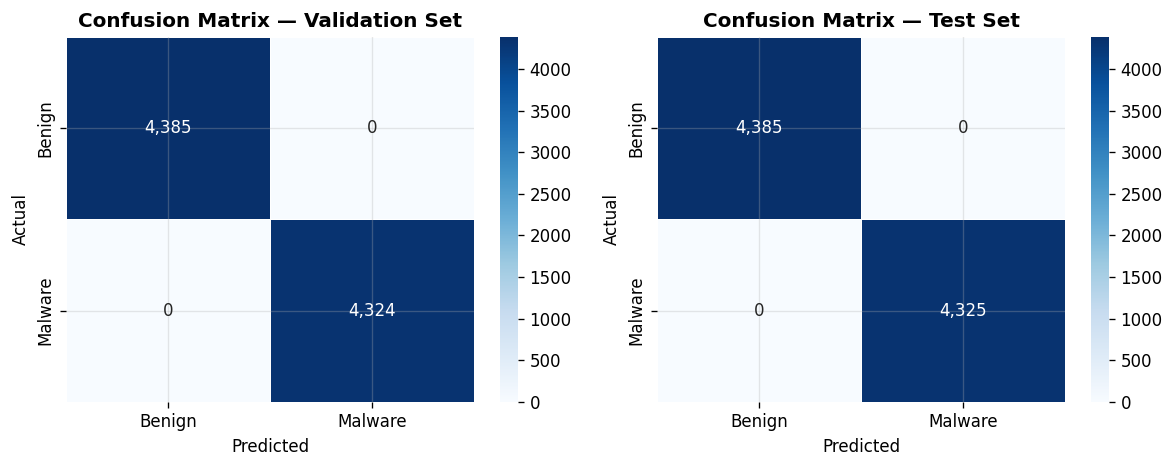

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in [
    (axes[0], y_val,  val_pred,  'Validation Set'),
    (axes[1], y_test, test_pred, 'Test Set'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt=',d', cmap='Blues',
        xticklabels=['Benign', 'Malware'],
        yticklabels=['Benign', 'Malware'],
        ax=ax, linewidths=0.5,
    )
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 6 · ROC & Precision-Recall Curves

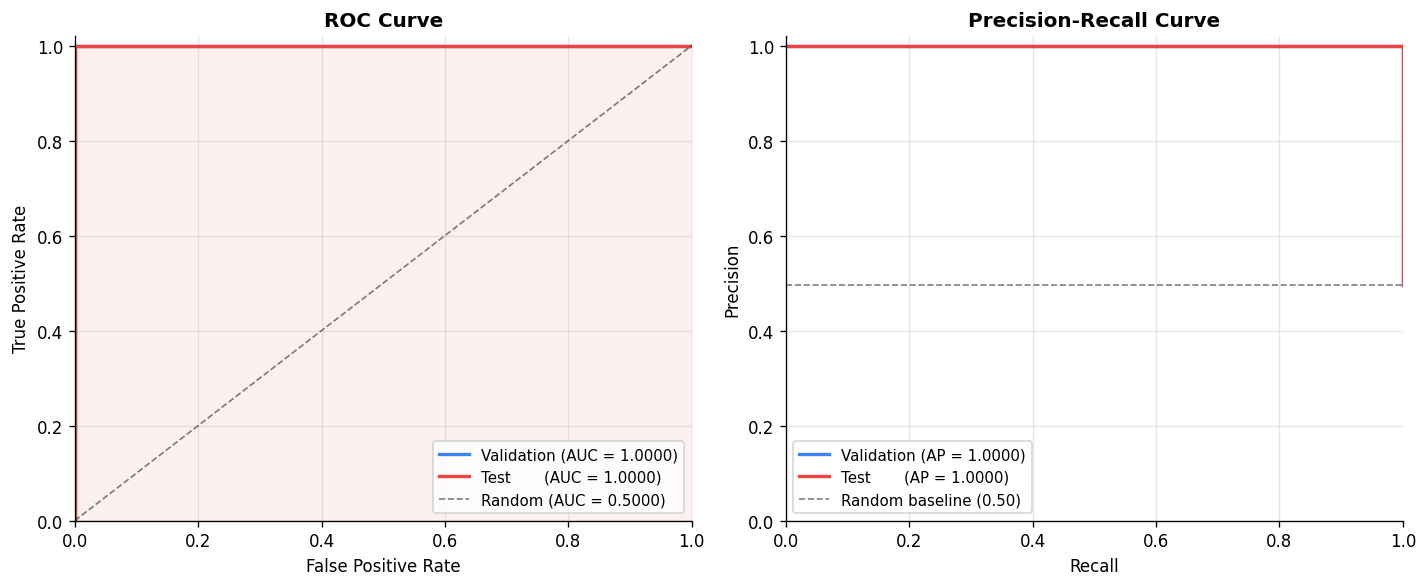

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── ROC ──────────────────────────────────────────────────────────────────────
ax = axes[0]
for y_true, y_proba, label, color in [
    (y_val,  val_proba,  f'Validation (AUC = {val_metrics["ROC-AUC"]:.4f})',  '#3B82F6'),
    (y_test, test_proba, f'Test       (AUC = {test_metrics["ROC-AUC"]:.4f})', '#EF4444'),
]:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax.plot(fpr, tpr, label=label, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5000)')
ax.fill_between(
    *roc_curve(y_test, test_proba)[:2],
    alpha=0.08, color='#EF4444'
)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

# ── Precision-Recall ─────────────────────────────────────────────────────────
ax = axes[1]
for y_true, y_proba, label, color in [
    (y_val,  val_proba,  f'Validation (AP = {val_metrics["PR-AUC (Avg Precision)"]:.4f})',  '#3B82F6'),
    (y_test, test_proba, f'Test       (AP = {test_metrics["PR-AUC (Avg Precision)"]:.4f})', '#EF4444'),
]:
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    ax.plot(rec, prec, label=label, color=color, linewidth=2)

baseline = y_test.mean()
ax.axhline(baseline, linestyle='--', color='k', linewidth=1, alpha=0.5,
           label=f'Random baseline ({baseline:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

## 7 · Per-Class Report

In [11]:
print('══ VALIDATION SET ══')
print(classification_report(y_val, val_pred, target_names=['Benign', 'Malware']))

print('══ TEST SET ══')
print(classification_report(y_test, test_pred, target_names=['Benign', 'Malware']))

══ VALIDATION SET ══
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4385
     Malware       1.00      1.00      1.00      4324

    accuracy                           1.00      8709
   macro avg       1.00      1.00      1.00      8709
weighted avg       1.00      1.00      1.00      8709

══ TEST SET ══
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      4385
     Malware       1.00      1.00      1.00      4325

    accuracy                           1.00      8710
   macro avg       1.00      1.00      1.00      8710
weighted avg       1.00      1.00      1.00      8710



## 8 · 5-Fold Cross-Validation

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from modules.config import CV_N_SPLITS, RF_RANDOM_STATE

cv = StratifiedKFold(n_splits=CV_N_SPLITS, shuffle=True, random_state=RF_RANDOM_STATE)

scoring = {
    'accuracy':  'accuracy',
    'f1_macro':  'f1_macro',
    'roc_auc':   'roc_auc',
    'precision': 'precision_macro',
    'recall':    'recall_macro',
}

cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

print(f'{'Metric':<25}  {'Mean':>8}  {'Std':>8}  Fold Scores')
print('─' * 75)
for metric, key in [
    ('Accuracy',        'test_accuracy'),
    ('F1 (Macro)',      'test_f1_macro'),
    ('ROC-AUC',         'test_roc_auc'),
    ('Precision (Macro)','test_precision'),
    ('Recall (Macro)',  'test_recall'),
]:
    scores = cv_results[key]
    fold_str = '  '.join(f'{s:.4f}' for s in scores)
    print(f'{metric:<25}  {scores.mean():.6f}  {scores.std():.6f}  {fold_str}')

Metric                         Mean       Std  Fold Scores
───────────────────────────────────────────────────────────────────────────
Accuracy                   0.999897  0.000100  1.0000  1.0000  0.9999  0.9998  0.9997
F1 (Macro)                 0.999897  0.000100  1.0000  1.0000  0.9999  0.9998  0.9997
ROC-AUC                    1.000000  0.000001  1.0000  1.0000  1.0000  1.0000  1.0000
Precision (Macro)          0.999896  0.000101  1.0000  1.0000  0.9999  0.9998  0.9997
Recall (Macro)             0.999897  0.000100  1.0000  1.0000  0.9999  0.9998  0.9997


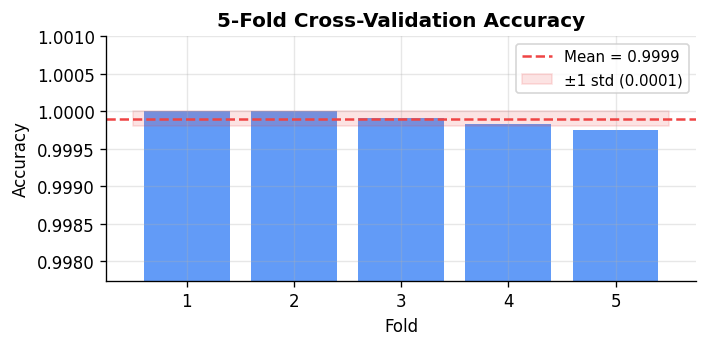

In [13]:
# CV accuracy distribution
fold_acc = cv_results['test_accuracy']

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, CV_N_SPLITS + 1), fold_acc, color='#3B82F6', alpha=0.8)
ax.axhline(fold_acc.mean(), color='#EF4444', linestyle='--', linewidth=1.5,
           label=f'Mean = {fold_acc.mean():.4f}')
ax.fill_between(
    [0.5, CV_N_SPLITS + 0.5],
    fold_acc.mean() - fold_acc.std(),
    fold_acc.mean() + fold_acc.std(),
    alpha=0.15, color='#EF4444', label=f'±1 std ({fold_acc.std():.4f})'
)
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title(f'{CV_N_SPLITS}-Fold Cross-Validation Accuracy', fontweight='bold')
ax.set_ylim(fold_acc.min() - 0.002, 1.001)
ax.set_xticks(range(1, CV_N_SPLITS + 1))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9 · Feature Importance

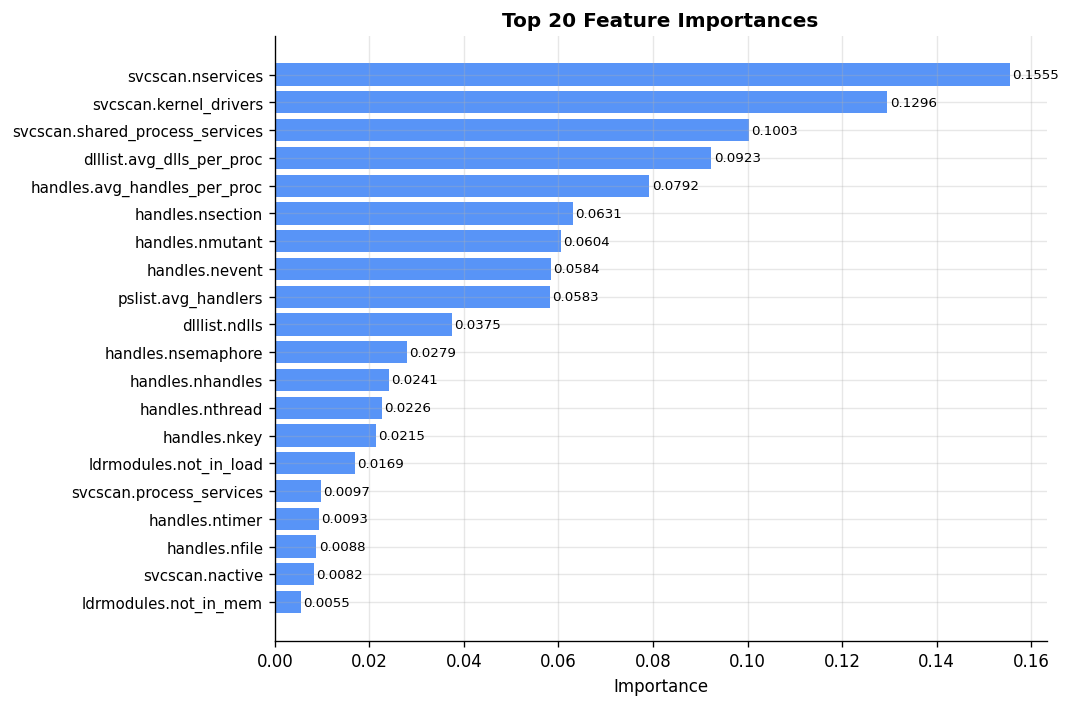

In [14]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 20

top_names  = [feature_names[i] for i in indices[:top_n]]
top_scores = importances[indices[:top_n]]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(range(top_n), top_scores[::-1], color='#3B82F6', alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title(f'Top {top_n} Feature Importances', fontweight='bold')

for bar, score in zip(bars, top_scores[::-1]):
    ax.text(score + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

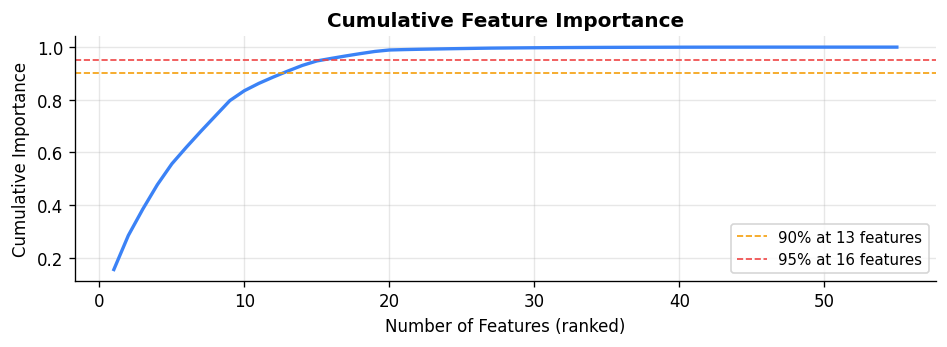

13 features explain 90% of model importance.
16 features explain 95% of model importance.


In [15]:
# Cumulative importance
cum_imp = np.cumsum(importances[indices])
n90 = np.searchsorted(cum_imp, 0.90) + 1
n95 = np.searchsorted(cum_imp, 0.95) + 1

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, len(cum_imp) + 1), cum_imp, color='#3B82F6', linewidth=2)
ax.axhline(0.90, color='#F59E0B', linestyle='--', linewidth=1, label=f'90% at {n90} features')
ax.axhline(0.95, color='#EF4444', linestyle='--', linewidth=1, label=f'95% at {n95} features')
ax.set_xlabel('Number of Features (ranked)')
ax.set_ylabel('Cumulative Importance')
ax.set_title('Cumulative Feature Importance', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'{n90} features explain 90% of model importance.')
print(f'{n95} features explain 95% of model importance.')

## 11 · Stage 2a — Category Classifier (Ransomware / Spyware / Trojan)

Trained on malicious-only samples (Benign rows excluded). 80/20 split, stratified.

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score,
)
from modules.family_classifier import DATASET_PATH, _NON_FEATURE_COLS
from modules.config import (
    SEC_N_ESTIMATORS, SEC_MAX_DEPTH, SEC_MIN_SAMPLES_LEAF,
    SEC_RANDOM_STATE, TRAIN_RATIO_SEC,
)

# ── Load malicious rows only ──────────────────────────────────────────────────
df = pd.read_csv(DATASET_PATH)
parts = df["Category"].str.split("-")
df["mal_type"]   = parts.str[0]
df["mal_family"] = parts.str[1]
df_mal = df[df["Class"] != "Benign"].copy()

feature_cols = [c for c in df.columns
                if c not in _NON_FEATURE_COLS and c not in ("mal_type","mal_family","Class")]
X_mal = df_mal[feature_cols].values.astype(np.float64)

cat_le = LabelEncoder()
y_cat  = cat_le.fit_transform(df_mal["mal_type"].values)

print(f"Malicious samples : {len(y_cat):,}")
print(f"Classes           : {dict(zip(cat_le.classes_, np.bincount(y_cat)))}")
print(f"Split             : {int(TRAIN_RATIO_SEC*100)}/{int((1-TRAIN_RATIO_SEC)*100)}")

# ── Train ─────────────────────────────────────────────────────────────────────
X_cat_tr, X_cat_te, y_cat_tr, y_cat_te = train_test_split(
    X_mal, y_cat, test_size=(1 - TRAIN_RATIO_SEC),
    random_state=SEC_RANDOM_STATE, stratify=y_cat,
)
cat_clf = RandomForestClassifier(
    n_estimators=SEC_N_ESTIMATORS, max_depth=SEC_MAX_DEPTH,
    min_samples_leaf=SEC_MIN_SAMPLES_LEAF,
    class_weight="balanced", random_state=SEC_RANDOM_STATE, n_jobs=-1,
)
cat_clf.fit(X_cat_tr, y_cat_tr)
y_cat_pred  = cat_clf.predict(X_cat_te)
y_cat_proba = cat_clf.predict_proba(X_cat_te)

# ── Metrics ───────────────────────────────────────────────────────────────────
cat_acc  = accuracy_score(y_cat_te, y_cat_pred)
cat_bacc = balanced_accuracy_score(y_cat_te, y_cat_pred)
cat_f1m  = f1_score(y_cat_te, y_cat_pred, average="macro")
cat_f1w  = f1_score(y_cat_te, y_cat_pred, average="weighted")
cat_prec = precision_score(y_cat_te, y_cat_pred, average="macro")
cat_rec  = recall_score(y_cat_te, y_cat_pred, average="macro")
cat_auc  = roc_auc_score(y_cat_te, y_cat_proba, multi_class="ovr", average="macro")

print(f"\n{'Metric':<30} {'Value':>10}")
print("─" * 42)
for label, val in [
    ("Accuracy",                cat_acc),
    ("Balanced Accuracy",       cat_bacc),
    ("Precision (Macro)",       cat_prec),
    ("Recall (Macro)",          cat_rec),
    ("F1 (Macro)",              cat_f1m),
    ("F1 (Weighted)",           cat_f1w),
    ("ROC-AUC (OvR Macro)",     cat_auc),
]:
    print(f"{label:<30} {val:>10.4f}")

print("\n── Per-Class Report ──")
print(classification_report(y_cat_te, y_cat_pred,
      target_names=cat_le.classes_, digits=4))


Malicious samples : 29,298
Classes           : {'Ransomware': np.int64(9791), 'Spyware': np.int64(10020), 'Trojan': np.int64(9487)}
Split             : 80/19



Metric                              Value
──────────────────────────────────────────
Accuracy                           0.7469
Balanced Accuracy                  0.7466
Precision (Macro)                  0.7467
Recall (Macro)                     0.7466
F1 (Macro)                         0.7466
F1 (Weighted)                      0.7471
ROC-AUC (OvR Macro)                0.8992

── Per-Class Report ──
              precision    recall  f1-score   support

  Ransomware     0.7343    0.7211    0.7276      1958
     Spyware     0.7895    0.7784    0.7839      2004
      Trojan     0.7165    0.7403    0.7282      1898

    accuracy                         0.7469      5860
   macro avg     0.7467    0.7466    0.7466      5860
weighted avg     0.7474    0.7469    0.7471      5860



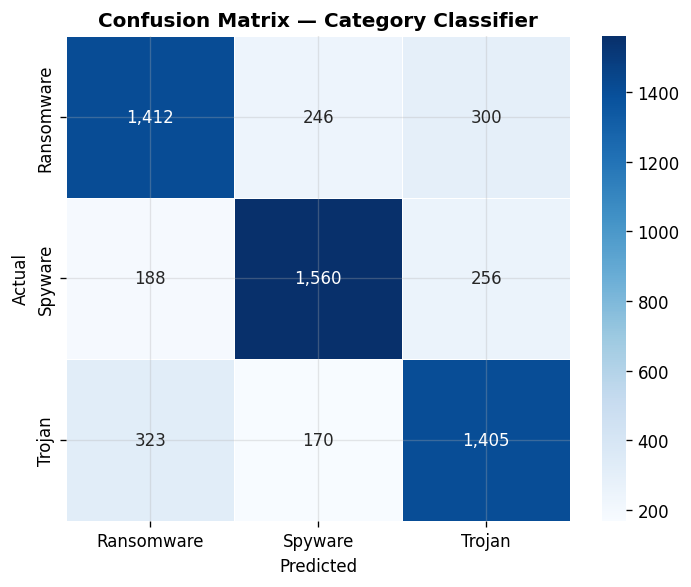

In [17]:
# Confusion matrix — category
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_cat_te, y_cat_pred)
sns.heatmap(
    cm, annot=True, fmt=",d", cmap="Blues",
    xticklabels=cat_le.classes_,
    yticklabels=cat_le.classes_,
    ax=ax, linewidths=0.5,
)
ax.set_title("Confusion Matrix — Category Classifier", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


In [18]:
# 5-fold CV on category classifier
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEC_RANDOM_STATE)
cat_cv = cross_validate(cat_clf, X_mal, y_cat, cv=cv,
                        scoring={"accuracy":"accuracy","f1_macro":"f1_macro","roc_auc":"roc_auc_ovr"},
                        n_jobs=-1)
print(f"Category CV Accuracy  : {cat_cv['test_accuracy'].mean():.4f} ± {cat_cv['test_accuracy'].std():.4f}")
print(f"Category CV F1 Macro  : {cat_cv['test_f1_macro'].mean():.4f} ± {cat_cv['test_f1_macro'].std():.4f}")
print(f"Category CV ROC-AUC   : {cat_cv['test_roc_auc'].mean():.4f} ± {cat_cv['test_roc_auc'].std():.4f}")


Category CV Accuracy  : 0.7480 ± 0.0067
Category CV F1 Macro  : 0.7476 ± 0.0067
Category CV ROC-AUC   : 0.8999 ± 0.0036


## 12 · Stage 2b — Family Classifier (15 Families)

Trained on malicious-only samples. 80/20 split, stratified. Families: Ako, Conti, Maze, Pysa, Shade (Ransomware) · 180solutions, CWS, Gator, TIBS, Transponder (Spyware) · Emotet, Reconyc, Refroso, Scar, Zeus (Trojan).

In [19]:
fam_le = LabelEncoder()
y_fam  = fam_le.fit_transform(df_mal["mal_family"].values)

print(f"Families ({len(fam_le.classes_)}) : {fam_le.classes_.tolist()}")
print(f"Samples  per family:")
for cls, cnt in zip(fam_le.classes_, np.bincount(y_fam)):
    print(f"  {cls:<18} {cnt:>5,}")

# ── Train ─────────────────────────────────────────────────────────────────────
X_fam_tr, X_fam_te, y_fam_tr, y_fam_te = train_test_split(
    X_mal, y_fam, test_size=(1 - TRAIN_RATIO_SEC),
    random_state=SEC_RANDOM_STATE, stratify=y_fam,
)
fam_clf = RandomForestClassifier(
    n_estimators=SEC_N_ESTIMATORS, max_depth=SEC_MAX_DEPTH,
    min_samples_leaf=SEC_MIN_SAMPLES_LEAF,
    class_weight="balanced", random_state=SEC_RANDOM_STATE, n_jobs=-1,
)
fam_clf.fit(X_fam_tr, y_fam_tr)
y_fam_pred  = fam_clf.predict(X_fam_te)
y_fam_proba = fam_clf.predict_proba(X_fam_te)

# ── Metrics ───────────────────────────────────────────────────────────────────
fam_acc  = accuracy_score(y_fam_te, y_fam_pred)
fam_bacc = balanced_accuracy_score(y_fam_te, y_fam_pred)
fam_f1m  = f1_score(y_fam_te, y_fam_pred, average="macro")
fam_f1w  = f1_score(y_fam_te, y_fam_pred, average="weighted")
fam_prec = precision_score(y_fam_te, y_fam_pred, average="macro")
fam_rec  = recall_score(y_fam_te, y_fam_pred, average="macro")
fam_auc  = roc_auc_score(y_fam_te, y_fam_proba, multi_class="ovr", average="macro")

print(f"\n{'Metric':<30} {'Value':>10}")
print("─" * 42)
for label, val in [
    ("Accuracy",                fam_acc),
    ("Balanced Accuracy",       fam_bacc),
    ("Precision (Macro)",       fam_prec),
    ("Recall (Macro)",          fam_rec),
    ("F1 (Macro)",              fam_f1m),
    ("F1 (Weighted)",           fam_f1w),
    ("ROC-AUC (OvR Macro)",     fam_auc),
]:
    print(f"{label:<30} {val:>10.4f}")

print("\n── Per-Family Report ──")
print(classification_report(y_fam_te, y_fam_pred,
      target_names=fam_le.classes_, digits=4))


Families (15) : ['180solutions', 'Ako', 'CWS', 'Conti', 'Emotet', 'Gator', 'Maze', 'Pysa', 'Reconyc', 'Refroso', 'Scar', 'Shade', 'TIBS', 'Transponder', 'Zeus']
Samples  per family:
  180solutions       2,000
  Ako                2,000
  CWS                2,000
  Conti              1,988
  Emotet             1,967
  Gator              2,200
  Maze               1,958
  Pysa               1,717
  Reconyc            1,570
  Refroso            2,000
  Scar               2,000
  Shade              2,128
  TIBS               1,410
  Transponder        2,410
  Zeus               1,950



Metric                              Value
──────────────────────────────────────────
Accuracy                           0.5184
Balanced Accuracy                  0.5206
Precision (Macro)                  0.5198
Recall (Macro)                     0.5206
F1 (Macro)                         0.5160
F1 (Weighted)                      0.5121
ROC-AUC (OvR Macro)                0.9087

── Per-Family Report ──
              precision    recall  f1-score   support

180solutions     0.4531    0.3500    0.3949       400
         Ako     0.4123    0.3350    0.3697       400
         CWS     0.4466    0.4075    0.4261       400
       Conti     0.4286    0.3769    0.4011       398
      Emotet     0.5479    0.5089    0.5277       393
       Gator     0.5495    0.7818    0.6454       440
        Maze     0.5569    0.4745    0.5124       392
        Pysa     0.4701    0.3440    0.3973       343
     Reconyc     0.5776    0.6401    0.6073       314
     Refroso     0.6907    0.7650    0.7260       400


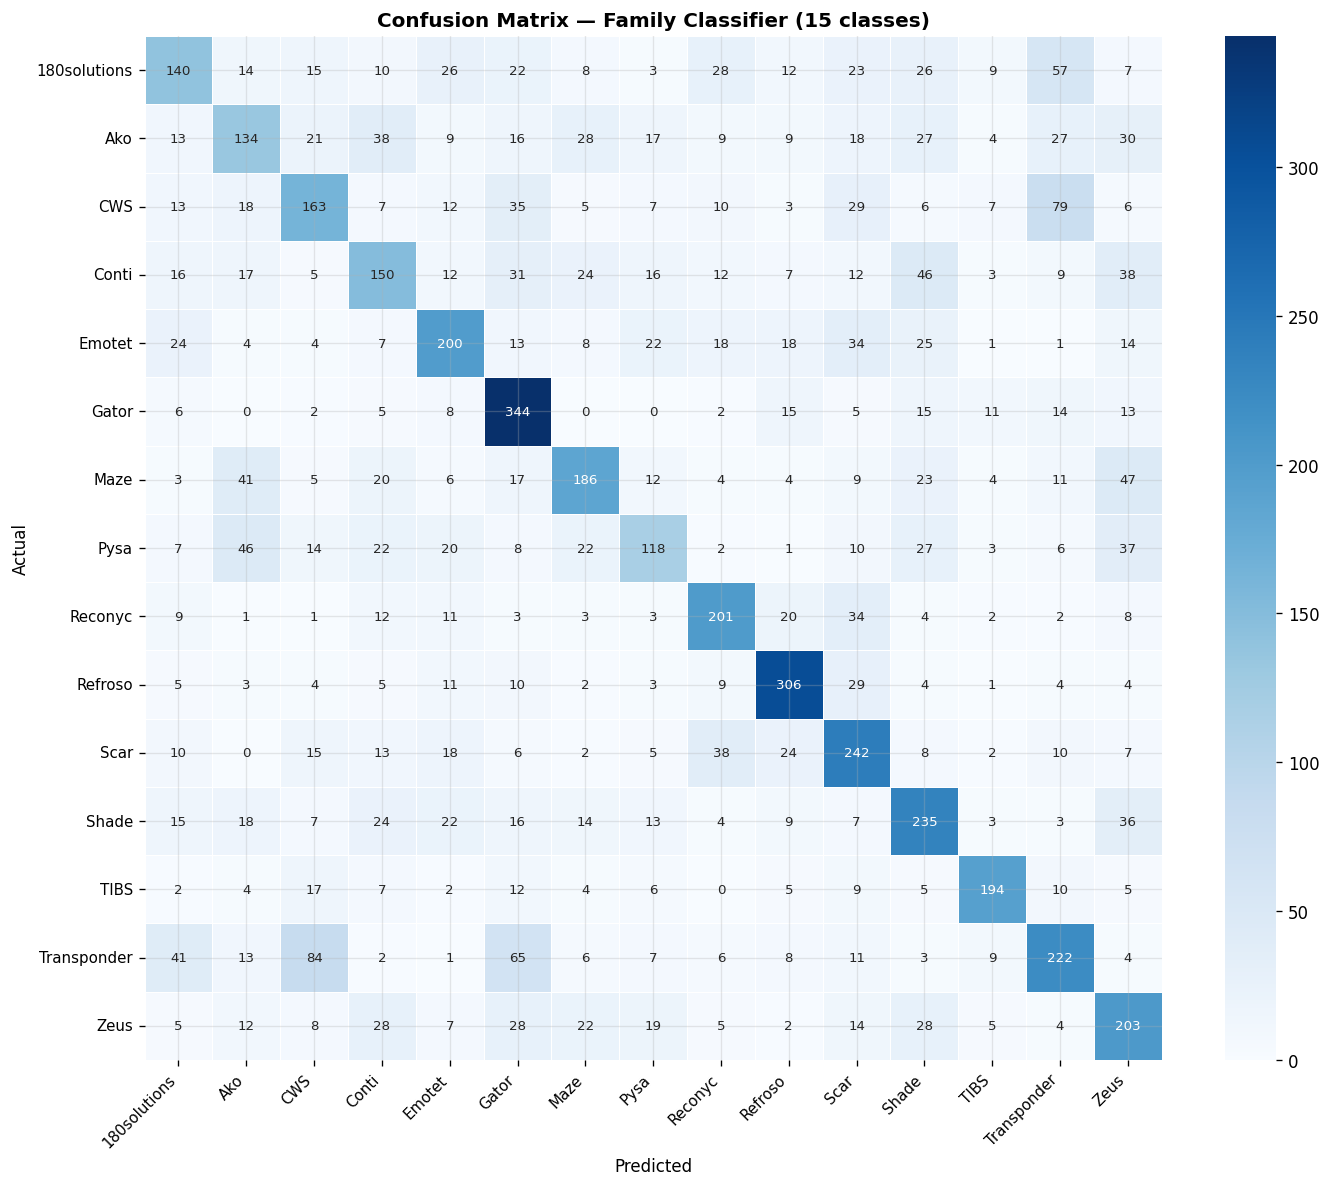

In [20]:
# Confusion matrix — families (15x15)
fig, ax = plt.subplots(figsize=(12, 10))
cm_fam = confusion_matrix(y_fam_te, y_fam_pred)
sns.heatmap(
    cm_fam, annot=True, fmt=",d", cmap="Blues",
    xticklabels=fam_le.classes_,
    yticklabels=fam_le.classes_,
    ax=ax, linewidths=0.4, annot_kws={"size": 8},
)
ax.set_title("Confusion Matrix — Family Classifier (15 classes)", fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


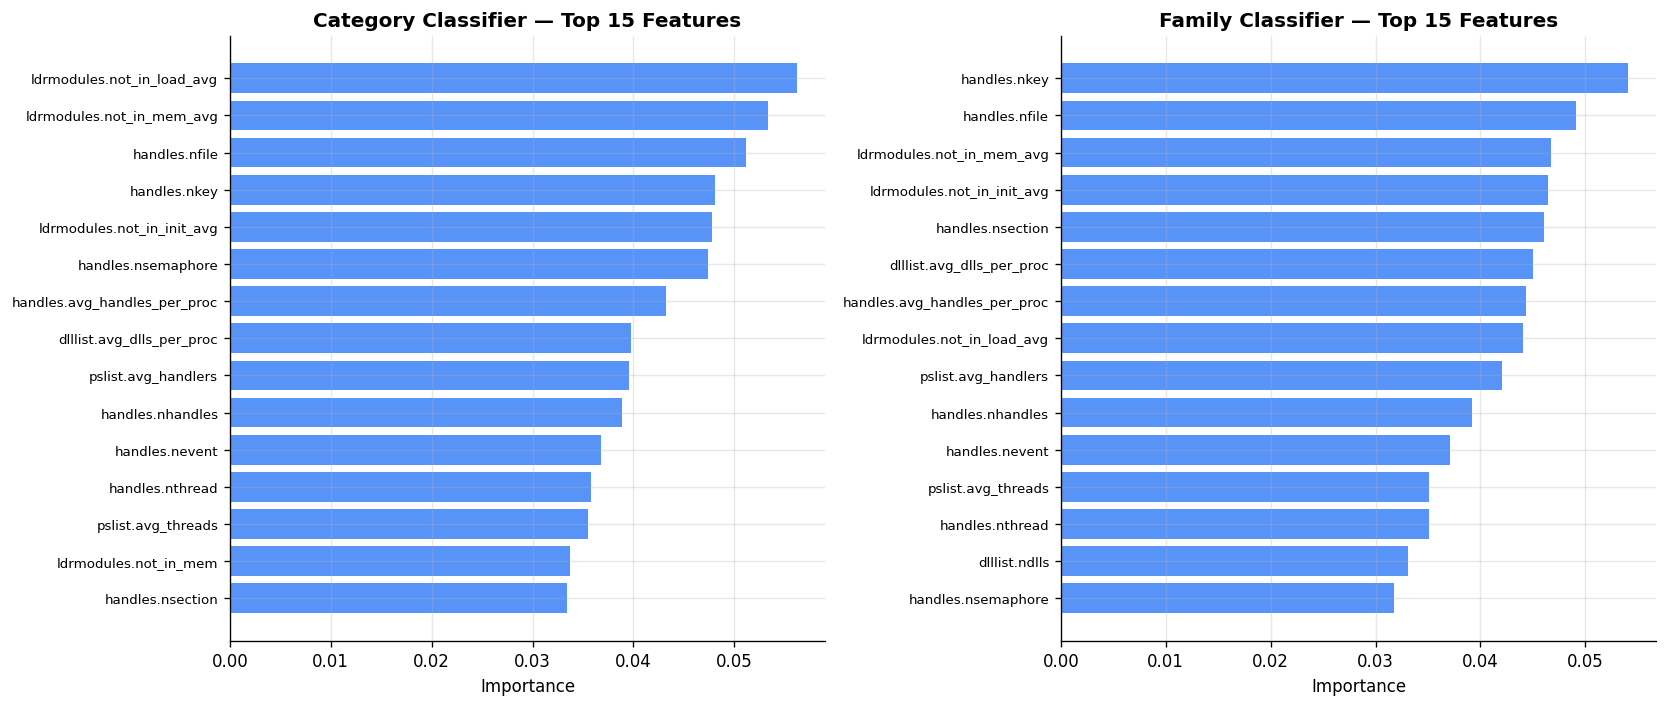

In [21]:
# Per-family feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, clf, le, title in [
    (axes[0], cat_clf, cat_le, "Category Classifier — Top 15 Features"),
    (axes[1], fam_clf, fam_le, "Family Classifier — Top 15 Features"),
]:
    imp = clf.feature_importances_
    idx = np.argsort(imp)[::-1][:15]
    names  = [feature_cols[i] for i in idx][::-1]
    scores = imp[idx][::-1]
    ax.barh(range(15), scores, color="#3B82F6", alpha=0.85)
    ax.set_yticks(range(15))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel("Importance")
    ax.set_title(title, fontweight="bold")
plt.tight_layout()
plt.show()


## 13 · Full Pipeline Summary

In [22]:
kappa = test_metrics["Cohen's Kappa"]

print("╔══════════════════════════════════════════════════════════════╗")
print("║             MEMSHIELD — FULL PIPELINE SUMMARY               ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  STAGE 1 — Binary Classifier (Malware vs Benign)            ║")
print("╠══════════════════════════════════════════════════════════════╣")
rows1 = [
    ("Accuracy (Test)",        f"{test_metrics['Accuracy']:.4f}"),
    ("Balanced Accuracy",      f"{test_metrics['Balanced Accuracy']:.4f}"),
    ("F1 Macro",               f"{test_metrics['F1 (Macro)']:.4f}"),
    ("ROC-AUC",                f"{test_metrics['ROC-AUC']:.4f}"),
    ("Sensitivity (TPR)",      f"{test_metrics['Recall / Sensitivity']:.4f}"),
    ("Specificity (TNR)",      f"{test_metrics['Specificity (TNR)']:.4f}"),
    ("False Positive Rate",    f"{test_metrics['False Positive Rate']:.4f}"),
    ("False Negative Rate",    f"{test_metrics['False Negative Rate']:.4f}"),
    ("MCC",                    f"{test_metrics['Matthews Corr. Coeff.']:.4f}"),
    ("CV Accuracy (5-fold)",   f"{cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}"),
]
for label, value in rows1:
    print(f"║  {label:<35} {value:>22}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  STAGE 2a — Category Classifier (3 classes)                 ║")
print("╠══════════════════════════════════════════════════════════════╣")
rows2 = [
    ("Accuracy (Test)",  f"{cat_acc:.4f}"),
    ("Balanced Accuracy",f"{cat_bacc:.4f}"),
    ("F1 Macro",         f"{cat_f1m:.4f}"),
    ("ROC-AUC (OvR)",    f"{cat_auc:.4f}"),
    ("CV Accuracy",      f"{cat_cv['test_accuracy'].mean():.4f} +/- {cat_cv['test_accuracy'].std():.4f}"),
]
for label, value in rows2:
    print(f"║  {label:<35} {value:>22}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  STAGE 2b — Family Classifier (15 families)                 ║")
print("╠══════════════════════════════════════════════════════════════╣")
rows3 = [
    ("Accuracy (Test)",  f"{fam_acc:.4f}"),
    ("Balanced Accuracy",f"{fam_bacc:.4f}"),
    ("F1 Macro",         f"{fam_f1m:.4f}"),
    ("ROC-AUC (OvR)",    f"{fam_auc:.4f}"),
]
for label, value in rows3:
    print(f"║  {label:<35} {value:>22}  ║")
print("╚══════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════╗
║             MEMSHIELD — FULL PIPELINE SUMMARY               ║
╠══════════════════════════════════════════════════════════════╣
║  STAGE 1 — Binary Classifier (Malware vs Benign)            ║
╠══════════════════════════════════════════════════════════════╣
║  Accuracy (Test)                                     1.0000  ║
║  Balanced Accuracy                                   1.0000  ║
║  F1 Macro                                            1.0000  ║
║  ROC-AUC                                             1.0000  ║
║  Sensitivity (TPR)                                   1.0000  ║
║  Specificity (TNR)                                   1.0000  ║
║  False Positive Rate                                 0.0000  ║
║  False Negative Rate                                 0.0000  ║
║  MCC                                                 1.0000  ║
║  CV Accuracy (5-fold)                     0.9999 +/- 0.0001  ║
╠══════════════════════════